Covid

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Loading dataset
url = "https://raw.githubusercontent.com/SR1608/Datasets/main/covid-data.csv"
df = pd.read_csv(url)

# High Level Data understanding:

Number of Rows and Columns:

In [ ]:
print("Shape of the dataset (rows, columns):", df.shape)


Shape of the dataset (rows, columns): (57394, 49)


Data types of Columns:

In [ ]:
print("\nData types of each column:\n",df.dtypes)


Data types of each column:
 iso_code                               object
continent                              object
location                               object
date                                   object
total_cases                           float64
new_cases                             float64
new_cases_smoothed                    float64
total_deaths                          float64
new_deaths                            float64
new_deaths_smoothed                   float64
total_cases_per_million               float64
new_cases_per_million                 float64
new_cases_smoothed_per_million        float64
total_deaths_per_million              float64
new_deaths_per_million                float64
new_deaths_smoothed_per_million       float64
reproduction_rate                     float64
icu_patients                          float64
icu_patients_per_million              float64
hosp_patients                         float64
hosp_patients_per_million             float64
weekl

Information about Data:

In [ ]:
print("\nDataFrame Info:\n")
print(df.info())

print("\nStatistical Description:\n")
#includeing 'all' gives stats for object columns too
print(df.describe(include='all'))



DataFrame Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57394 entries, 0 to 57393
Data columns (total 49 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   iso_code                            57071 non-null  object 
 1   continent                           56748 non-null  object 
 2   location                            57394 non-null  object 
 3   date                                57394 non-null  object 
 4   total_cases                         53758 non-null  float64
 5   new_cases                           56465 non-null  float64
 6   new_cases_smoothed                  55652 non-null  float64
 7   total_deaths                        44368 non-null  float64
 8   new_deaths                          56465 non-null  float64
 9   new_deaths_smoothed                 55652 non-null  float64
 10  total_cases_per_million             53471 non-null  float64
 11  new_cases_per_million  

# Low Level Data Understanding:

Count of unique values in location column:

In [ ]:
print("Unique locations:", df['location'].nunique())

Unique locations: 216


Continent with Maximum Frequency:

In [ ]:
print("\nContinent with max frequency:")
print(df['continent'].value_counts().idxmax())


Continent with max frequency:
Europe


Maximum & Mean value in 'total_cases' :

In [ ]:
print("\nMax total_cases:", df['total_cases'].max())
print("Mean total_cases:", df['total_cases'].mean())


Max total_cases: 55154651.0
Mean total_cases: 167797.3688753302


25%, 50%, and 75% quartile values in 'total_deaths':

In [ ]:
print("\nQuartiles of total_deaths:")
print(df['total_deaths'].quantile([0.25, 0.50, 0.75]))


Quartiles of total_deaths:
0.25     13.0
0.50     84.0
0.75    727.0
Name: total_deaths, dtype: float64


Continent with maximum 'human_development_index' :

In [ ]:
max_hdi_row = df[df['human_development_index'] == df['human_development_index'].max()]
print("\nContinent with maximum HDI:", max_hdi_row['continent'].values[0])


Continent with maximum HDI: Europe


Continent with minimum 'gdp_per_capita' :

In [ ]:
min_gdp_row = df[df['gdp_per_capita'] == df['gdp_per_capita'].min()]
print("\nContinent with minimum GDP per capita:", min_gdp_row['continent'].values[0])


Continent with minimum GDP per capita: Africa


# Filtering the Dataframe with particular columns:

In [ ]:
#Filter and update the DataFrame
df = df[['continent', 'location', 'date', 'total_cases', 'total_deaths', 'gdp_per_capita', 'human_development_index']]

#Confirm updated DataFrame
print("Updated columns:\n", df.columns)
print("\nSample data:\n", df.head())

Updated columns:
 Index(['continent', 'location', 'date', 'total_cases', 'total_deaths',
       'gdp_per_capita', 'human_development_index'],
      dtype='object')

Sample data:
   continent     location      date  total_cases  total_deaths  gdp_per_capita  \
0      Asia  Afghanistan  31/12/19          NaN           NaN        1803.987   
1      Asia  Afghanistan  01/01/20          NaN           NaN        1803.987   
2      Asia  Afghanistan  02/01/20          NaN           NaN        1803.987   
3      Asia  Afghanistan  03/01/20          NaN           NaN        1803.987   
4      Asia  Afghanistan  04/01/20          NaN           NaN        1803.987   

   human_development_index  
0                    0.498  
1                    0.498  
2                    0.498  
3                    0.498  
4                    0.498  


# Data Cleaning :

Removing Duplicates :

In [ ]:
df = df.drop_duplicates()
print("Duplicates removed. New shape:", df.shape)

Duplicates removed. New shape: (57394, 7)


Find Missing Values in All Columns :

In [ ]:
print("\nMissing values in each column:\n")
print(df.isnull().sum())


Missing values in each column:

continent                    646
location                       0
date                           0
total_cases                 3636
total_deaths               13026
gdp_per_capita              7027
human_development_index     8147
dtype: int64


 Remove Rows Where continent Is Missing :

In [ ]:
df = df.dropna(subset=['continent'])
print("\nRows with missing 'continent' removed. New shape:", df.shape)


Rows with missing 'continent' removed. New shape: (56748, 7)


Fill All Remaining Missing Values with 0 :

In [ ]:
df = df.fillna(0)
print("\nAll remaining missing values filled with 0.\n")


All remaining missing values filled with 0.



# Date Time Format :

Convert date column to datetime format :

In [ ]:
df['date'] = pd.to_datetime(df['date'])
print("Date column converted to datetime format.")

Date column converted to datetime format.


<ipython-input-48-1100776463>:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['date'])


Create a new column month from date :

In [ ]:
df['month'] = df['date'].dt.month
print("Month column created from date.")
print(df[['date', 'month']].head())

Month column created from date.
        date  month
0 2019-12-31     12
1 2020-01-01      1
2 2020-02-01      2
3 2020-03-01      3
4 2020-04-01      4


# Data Aggregation :

Group by continent and find the max of all columns :

In [ ]:
df_groupby = df.groupby('continent').max().reset_index()

Store Result in New DataFrame df_groupby :

In [ ]:
print("Aggregated DataFrame (df_groupby):\n")
print(df_groupby)

Aggregated DataFrame (df_groupby):

       continent                      location       date  total_cases  \
0         Africa                      Zimbabwe 2020-12-11     752269.0   
1           Asia                         Yemen 2020-12-11    8874290.0   
2         Europe                       Vatican 2020-12-11    1991233.0   
3  North America  United States Virgin Islands 2020-12-11   11205486.0   
4        Oceania             Wallis and Futuna 2020-12-11      27750.0   
5  South America                     Venezuela 2020-12-11    5876464.0   

   total_deaths  gdp_per_capita  human_development_index  month  
0       20314.0       26382.287                    0.797     12  
1      130519.0      116935.600                    0.933     12  
2       52147.0       94277.965                    0.953     12  
3      247220.0       54225.446                    0.926     12  
4         907.0       44648.710                    0.939     12  
5      166014.0       22767.037                  

# Feature Engineering :

Create total_deaths_to_total_cases Column :

In [ ]:
df_groupby['total_deaths_to_total_cases'] = np.where(
    df_groupby['total_cases'] != 0,
    df_groupby['total_deaths'] / df_groupby['total_cases'],
    0)

# Data Visualization :

Univariate Analysis: Histogram of gdp_per_capita:

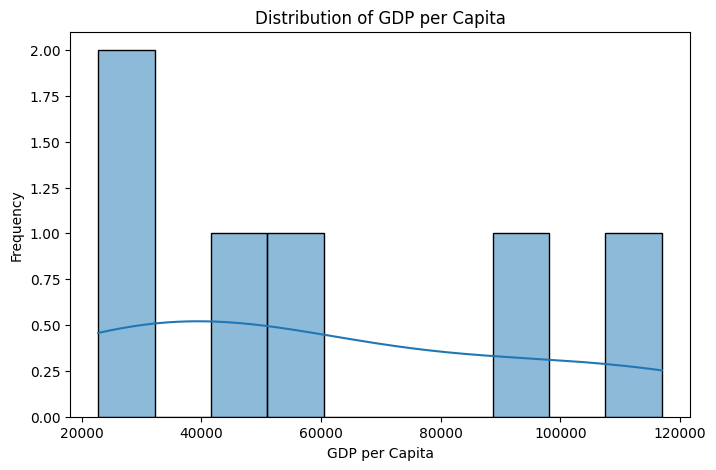

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df_groupby['gdp_per_capita'], kde=True, bins=10)
plt.title('Distribution of GDP per Capita')
plt.xlabel('GDP per Capita')
plt.ylabel('Frequency')
plt.show()

Scatter Plot: total_cases vs gdp_per_capita:

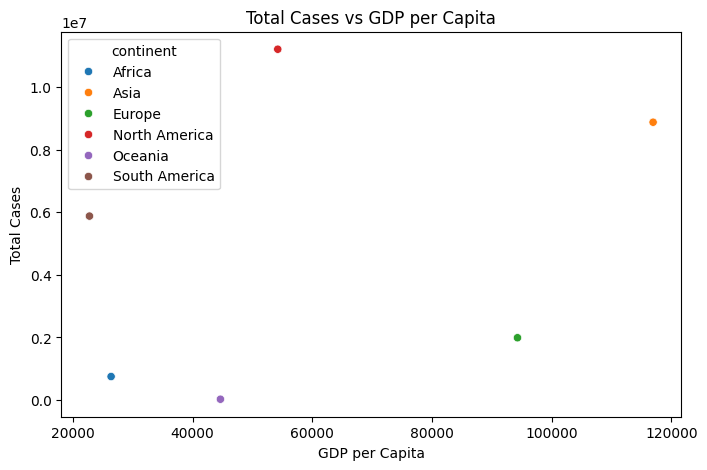

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_groupby, x='gdp_per_capita', y='total_cases', hue='continent')
plt.title('Total Cases vs GDP per Capita')
plt.xlabel('GDP per Capita')
plt.ylabel('Total Cases')
plt.show()

Pairplot on df_groupby :


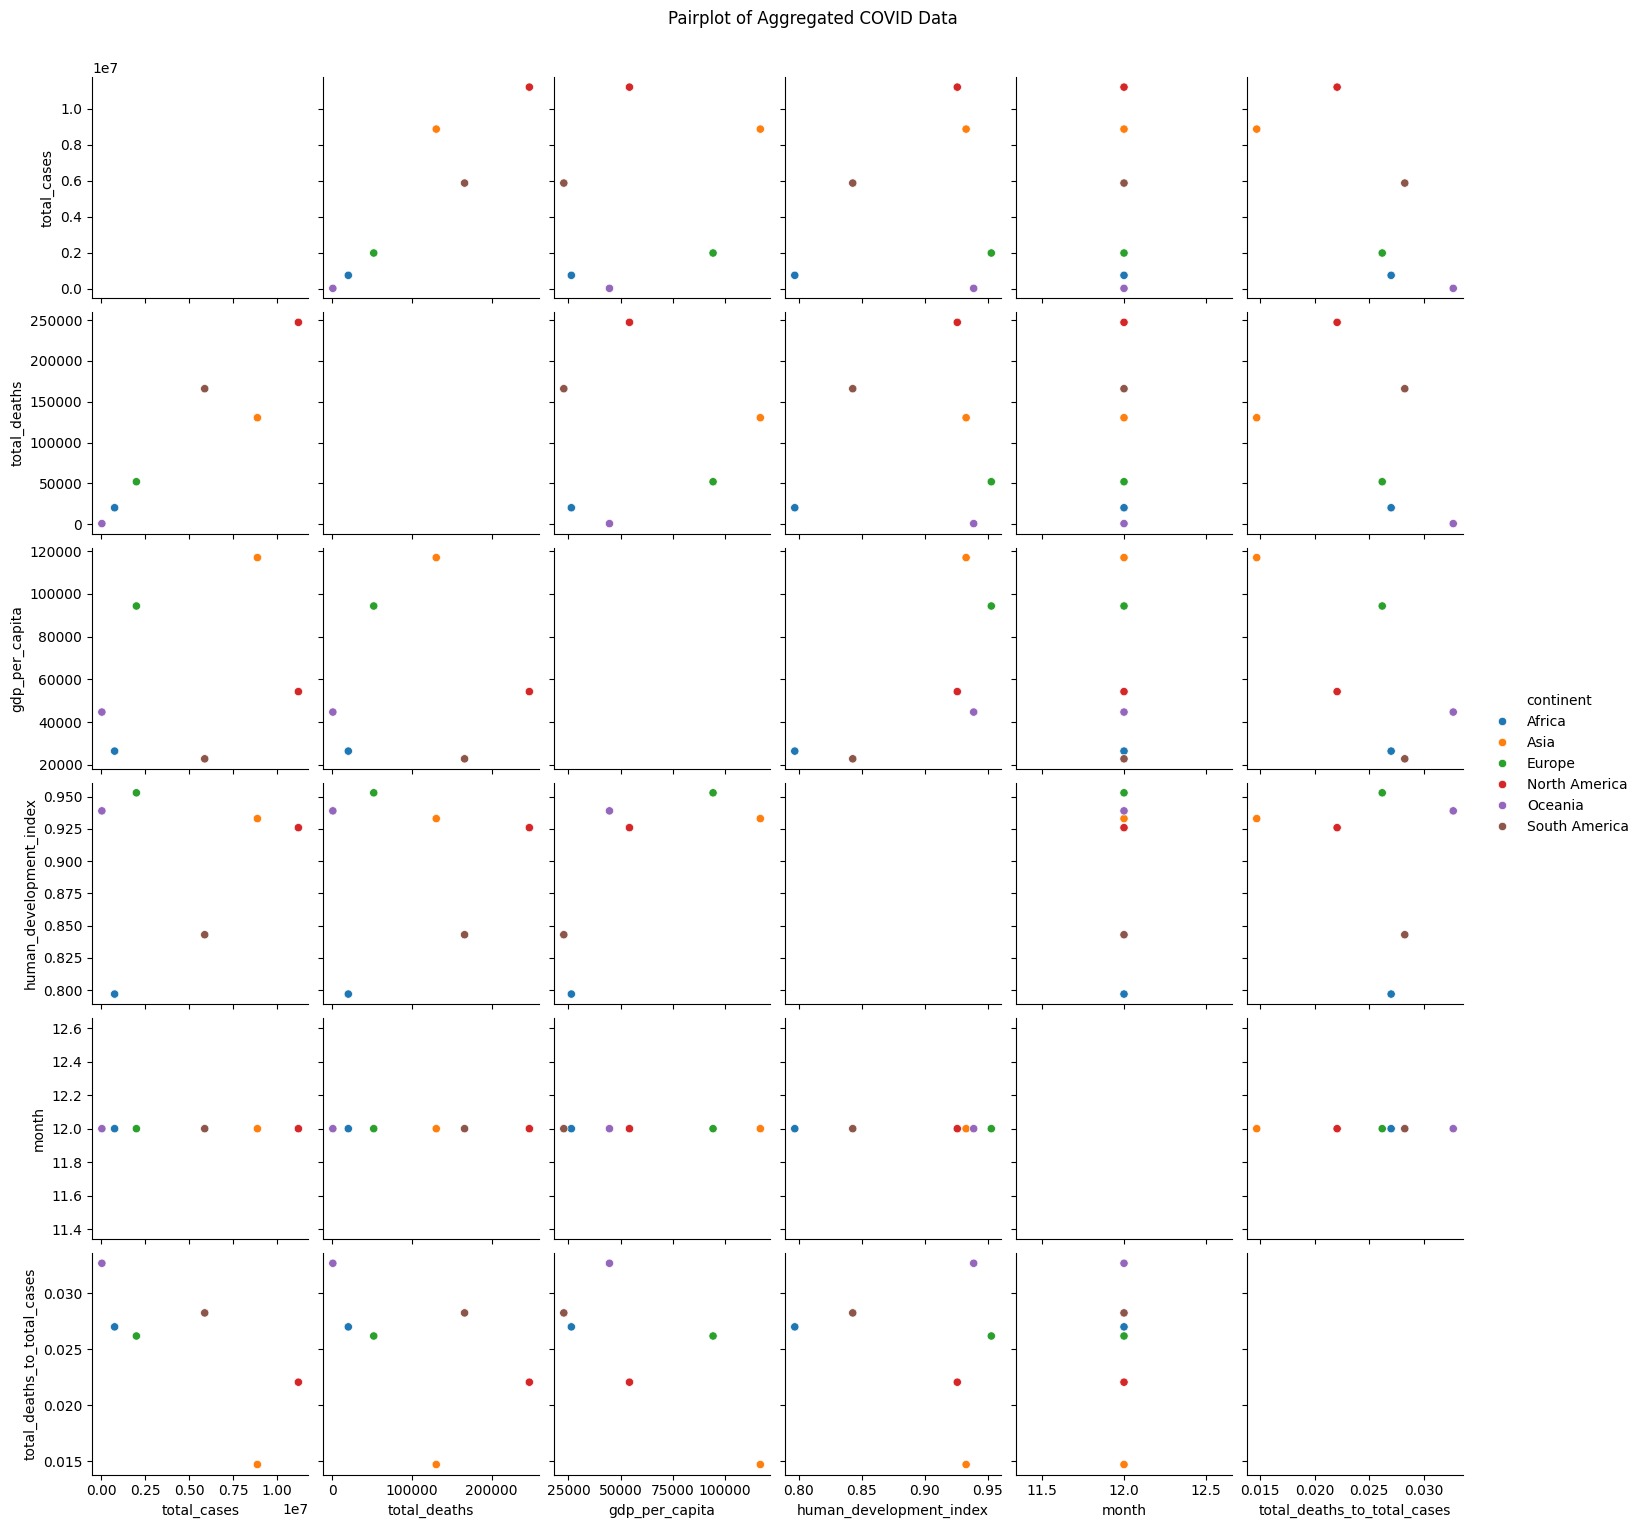

In [ ]:
sns.pairplot(df_groupby, hue='continent')
plt.suptitle("Pairplot of Aggregated COVID Data", y=1.02)
plt.show()

Bar Plot: Continent vs Total Cases :

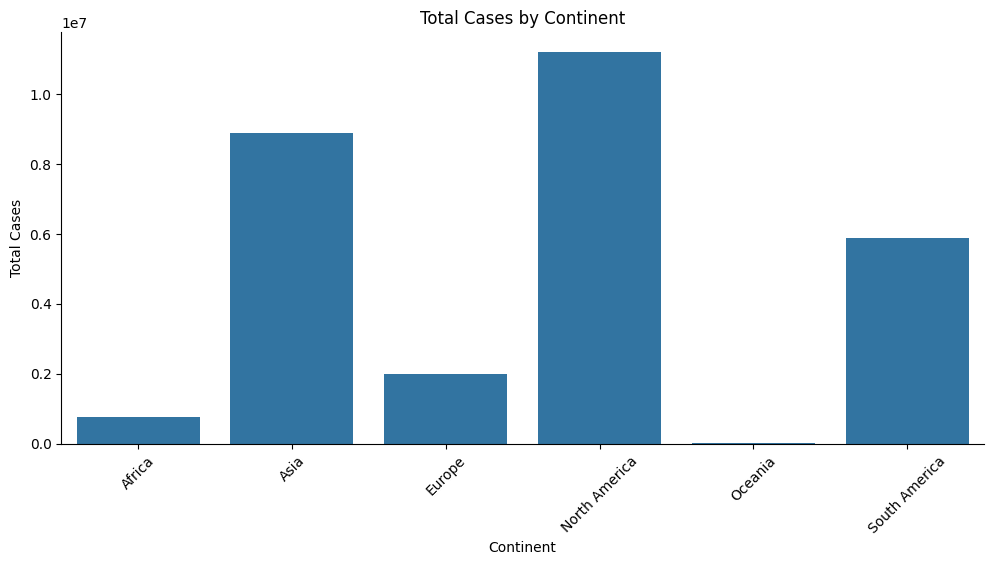

In [ ]:
sns.catplot(data=df_groupby, x='continent', y='total_cases', kind='bar', height=5, aspect=2)
plt.title('Total Cases by Continent')
plt.xlabel('Continent')
plt.ylabel('Total Cases')
plt.xticks(rotation=45)
plt.show()

Save the df_groupby dataframe :

In [ ]:
#Save df_groupby to CSV
df_groupby.to_csv('df_groupby_covid_analysis.csv', index=False)
print("df_groupby saved successfully as 'df_groupby_covid_analysis.csv'")

df_groupby saved successfully as 'df_groupby_covid_analysis.csv'


In [ ]:
df1 = pd.read_csv("df_groupby_covid_analysis.csv")

In [ ]:
print("Shape of the Filtered data: ",df1.shape)

Shape of the Filtered data:  (6, 9)


In [ ]:
print("Data :\n")
print(df1)

Data :

       continent                      location        date  total_cases  \
0         Africa                      Zimbabwe  2020-12-11     752269.0   
1           Asia                         Yemen  2020-12-11    8874290.0   
2         Europe                       Vatican  2020-12-11    1991233.0   
3  North America  United States Virgin Islands  2020-12-11   11205486.0   
4        Oceania             Wallis and Futuna  2020-12-11      27750.0   
5  South America                     Venezuela  2020-12-11    5876464.0   

   total_deaths  gdp_per_capita  human_development_index  month  \
0       20314.0       26382.287                    0.797     12   
1      130519.0      116935.600                    0.933     12   
2       52147.0       94277.965                    0.953     12   
3      247220.0       54225.446                    0.926     12   
4         907.0       44648.710                    0.939     12   
5      166014.0       22767.037                    0.843     12 